=== Inputs ===
ADM2: ZMB_adm2_gadm41_Copperbelt.shp | features: 12 | CRS: EPSG:4326
WorldPop: zmb_ppp_2020_constrained.tif | CRS: EPSG:4326 | res: (0.00083333333, 0.00083333333) | shape: (11826, 14047) | nodata: -99999.0 | dtype: float32
SMOD L1: task4_smod_L1_from_L2_54009_1km_INT16.tif
all_touched: False

Saved aligned SMOD: C:\Users\am636\copperbelt_worldpop_smod\outputs\task6_smodL1_aligned_to_worldpop.tif

=== Alignment verification (WorldPop vs aligned SMOD) ===
              check status                                                                            expected                                                                               found
           CRS EPSG   PASS                                                                                4326                                                                                4326
 Transform (affine)   PASS (0.00083333333, 0.0, 21.99958326, 0.0, -0.00083333333, -8.224583099, 0.0, 0.0, 1.0) (0.00083333333, 0.0, 21.99

KeyError: 'NAME_2'

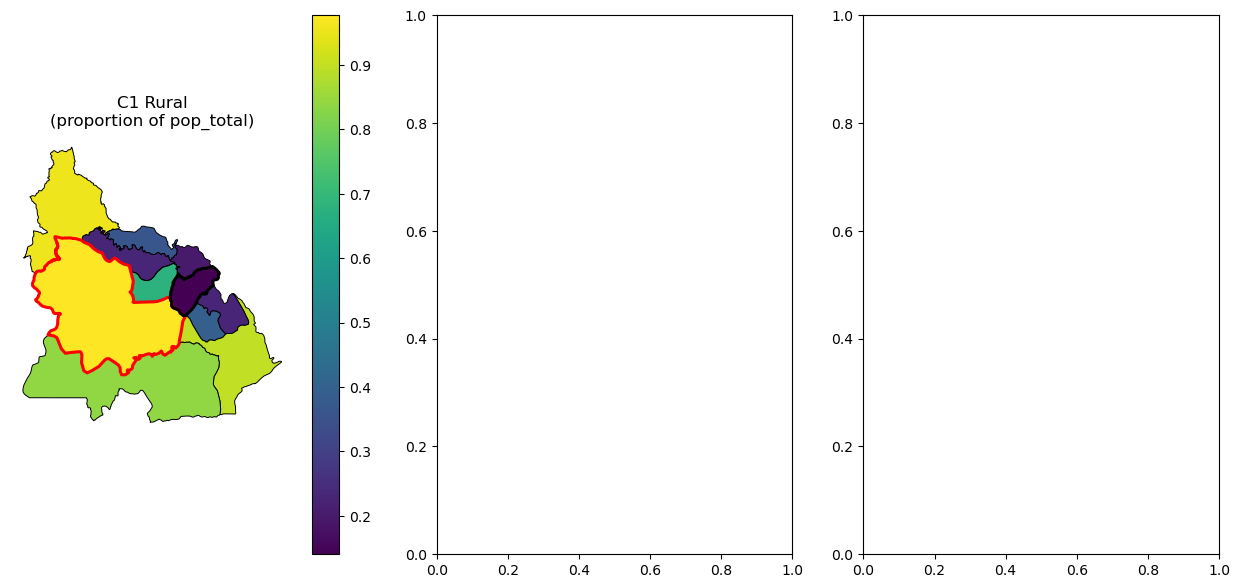

In [1]:
from pathlib import Path
import json
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.features import geometry_window, geometry_mask

import matplotlib.pyplot as plt


# =============================================================================
# Task 6 — Population totals and proportions by SMOD L1 within each ADM2
# Change requested: remove Min/Max text annotations on the ranked bar panels.
#
# Outputs (all prefixed with task6_):
#   outputs/ : aligned SMOD GeoTIFF + QA JSON
#   tables/  : CSVs
#   figures/ : PNGs
# =============================================================================

# ----------------------------
# Project structure
# ----------------------------
ROOT = Path(r"C:\Users\am636\copperbelt_worldpop_smod")

DATA = ROOT / "data_raw"
OUT = ROOT / "outputs"
TABDIR = ROOT / "tables"
FIGDIR = ROOT / "figures"

for d in (DATA, OUT, TABDIR, FIGDIR):
    d.mkdir(parents=True, exist_ok=True)

PREFIX = "task6_"

# Inputs
boundary_path = DATA / "ZMB_adm2_gadm41_Copperbelt.shp"
pop_path = DATA / "zmb_ppp_2020_constrained.tif"
smod_l1_path = OUT / "task4_smod_L1_from_L2_54009_1km_INT16.tif"

missing = [p for p in (boundary_path, pop_path, smod_l1_path) if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required input file(s):\n" + "\n".join(str(p) for p in missing))

# Key fields
GID_FIELD = "GID_2"
NAME_FIELD = "NAME_2"

# Controls
ALL_TOUCHED = False
SMOD_NODATA_EXPECTED = -200

run_time_utc = datetime.now(timezone.utc).isoformat(timespec="seconds")


# ----------------------------
# Outputs
# ----------------------------
aligned_smod_path = OUT / f"{PREFIX}smodL1_aligned_to_worldpop.tif"

district_csv = TABDIR / f"{PREFIX}pop_by_smodL1_by_adm2.csv"
extremes_csv = TABDIR / f"{PREFIX}extremes_by_class.csv"
qa_json = OUT / f"{PREFIX}alignment_and_closure_QA.json"

stacked_png = FIGDIR / f"{PREFIX}stacked_proportions_bar.png"
ranked_png = FIGDIR / f"{PREFIX}ranked_proportions_by_class.png"
maps_png = FIGDIR / f"{PREFIX}maps_proportions_by_class.png"


# ----------------------------
# Helpers
# ----------------------------
def safe_sum(arr: np.ndarray) -> float:
    return float(np.sum(arr, dtype=np.float64))

def _tuple_transform(t: rasterio.Affine) -> tuple:
    return tuple([round(float(x), 12) for x in t])

def _bounds_tuple(b: rasterio.coords.BoundingBox) -> tuple:
    return (
        round(float(b.left), 12), round(float(b.bottom), 12),
        round(float(b.right), 12), round(float(b.top), 12)
    )

def _res_from_transform(t: rasterio.Affine) -> tuple:
    return (round(float(t.a), 12), round(float(-t.e), 12))

def extreme_ids(df_in: pd.DataFrame, value_col: str, id_col: str, name_col: str):
    tmp = df_in[[id_col, name_col, value_col]].copy()
    tmp = tmp[np.isfinite(tmp[value_col].values)]
    if tmp.empty:
        return (np.nan, [], [], np.nan, [], [])
    vmin = tmp[value_col].min()
    vmax = tmp[value_col].max()
    min_rows = tmp[tmp[value_col] == vmin]
    max_rows = tmp[tmp[value_col] == vmax]
    return (
        float(vmin),
        min_rows[id_col].astype(str).tolist(),
        min_rows[name_col].astype(str).tolist(),
        float(vmax),
        max_rows[id_col].astype(str).tolist(),
        max_rows[name_col].astype(str).tolist()
    )


# ----------------------------
# 1) Read ADM2 boundaries
# ----------------------------
gdf = gpd.read_file(boundary_path)
if gdf.crs is None:
    raise ValueError("Boundary CRS is missing.")

for f in [GID_FIELD, NAME_FIELD]:
    if f not in gdf.columns:
        raise ValueError(f"Missing required field '{f}'. Available: {list(gdf.columns)}")

gdf = gdf.to_crs("EPSG:4326")


# ----------------------------
# 2) Open WorldPop (reference grid)
# ----------------------------
with rasterio.open(pop_path) as pop_ds:
    pop_crs = pop_ds.crs
    pop_transform = pop_ds.transform
    pop_width, pop_height = pop_ds.width, pop_ds.height
    pop_bounds = pop_ds.bounds
    pop_nodata = pop_ds.nodata
    pop_dtype = pop_ds.dtypes[0]

if pop_crs is None:
    raise ValueError("WorldPop CRS is missing.")
if pop_nodata is None:
    raise ValueError("WorldPop NoData is missing.")

pop_res = _res_from_transform(pop_transform)

print("=== Inputs ===")
print("ADM2:", boundary_path.name, "| features:", len(gdf), "| CRS:", gdf.crs)
print("WorldPop:", pop_path.name, "| CRS:", pop_crs, "| res:", pop_res, "| shape:", (pop_height, pop_width),
      "| nodata:", pop_nodata, "| dtype:", pop_dtype)
print("SMOD L1:", smod_l1_path.name)
print("all_touched:", ALL_TOUCHED)
print()


# ----------------------------
# 3) Align SMOD L1 onto WorldPop grid (nearest)
# ----------------------------
with rasterio.open(smod_l1_path) as smod_ds:
    smod_crs = smod_ds.crs
    smod_transform = smod_ds.transform
    smod_nodata = smod_ds.nodata
    smod_dtype = smod_ds.dtypes[0]
    smod_l1 = smod_ds.read(1)

if smod_crs is None:
    raise ValueError("SMOD CRS is missing.")
if smod_nodata is None:
    smod_nodata = SMOD_NODATA_EXPECTED

dest_smod = np.full((pop_height, pop_width), int(smod_nodata), dtype=np.int16)

reproject(
    source=smod_l1.astype(np.int16, copy=False),
    destination=dest_smod,
    src_transform=smod_transform,
    src_crs=smod_crs,
    src_nodata=int(smod_nodata),
    dst_transform=pop_transform,
    dst_crs=pop_crs,
    dst_nodata=int(smod_nodata),
    resampling=Resampling.nearest,
)

aligned_profile = {
    "driver": "GTiff",
    "height": pop_height,
    "width": pop_width,
    "count": 1,
    "dtype": rasterio.int16,
    "crs": pop_crs,
    "transform": pop_transform,
    "nodata": int(smod_nodata),
    "compress": "LZW",
}

with rasterio.open(aligned_smod_path, "w", **aligned_profile) as dst:
    dst.write(dest_smod, 1)

print("Saved aligned SMOD:", aligned_smod_path)
print()


# ----------------------------
# 3B) Verify alignment on disk (critical checks)
# ----------------------------
alignment_rows = []
critical_fail = False

with rasterio.open(pop_path) as pop_ds, rasterio.open(aligned_smod_path) as smod_aligned_ds:
    pop_epsg = pop_ds.crs.to_epsg() if pop_ds.crs else None
    smod_epsg = smod_aligned_ds.crs.to_epsg() if smod_aligned_ds.crs else None

    pop_tr = _tuple_transform(pop_ds.transform)
    smod_tr = _tuple_transform(smod_aligned_ds.transform)

    pop_res2 = _res_from_transform(pop_ds.transform)
    smod_res2 = _res_from_transform(smod_aligned_ds.transform)

    pop_wh = (int(pop_ds.width), int(pop_ds.height))
    smod_wh = (int(smod_aligned_ds.width), int(smod_aligned_ds.height))

    pop_bounds2 = _bounds_tuple(pop_ds.bounds)
    smod_bounds2 = _bounds_tuple(smod_aligned_ds.bounds)

    checks = [
        ("CRS EPSG", pop_epsg, smod_epsg, True),
        ("Transform (affine)", pop_tr, smod_tr, True),
        ("Pixel size", pop_res2, smod_res2, True),
        ("Width/Height", pop_wh, smod_wh, True),
        ("Bounds", pop_bounds2, smod_bounds2, True),
        ("Aligned SMOD dtype", "int16", str(smod_aligned_ds.dtypes[0]), False),
        ("Aligned SMOD NoData", str(int(SMOD_NODATA_EXPECTED)),
         str(int(smod_aligned_ds.nodata)) if smod_aligned_ds.nodata is not None else "None", False),
    ]

    for name, expected, found, is_critical in checks:
        ok = (expected == found)
        status = "PASS" if ok else ("FAIL" if is_critical else "WARN")
        alignment_rows.append({"check": name, "status": status, "expected": str(expected), "found": str(found)})
        if (not ok) and is_critical:
            critical_fail = True

alignment_df = pd.DataFrame(alignment_rows)

print("=== Alignment verification (WorldPop vs aligned SMOD) ===")
print(alignment_df.to_string(index=False))
print()

dst_transform_equals_worldpop = bool((alignment_df.loc[alignment_df["check"] == "Transform (affine)", "status"].values[0] == "PASS"))
dst_shape_equals_worldpop = bool((alignment_df.loc[alignment_df["check"] == "Width/Height", "status"].values[0] == "PASS"))
dst_bounds_equals_worldpop = bool((alignment_df.loc[alignment_df["check"] == "Bounds", "status"].values[0] == "PASS"))
dst_crs_equals_worldpop = bool((alignment_df.loc[alignment_df["check"] == "CRS EPSG", "status"].values[0] == "PASS"))
dst_res_equals_worldpop = bool((alignment_df.loc[alignment_df["check"] == "Pixel size", "status"].values[0] == "PASS"))

if critical_fail:
    raise RuntimeError("Alignment verification FAILED (critical mismatch).")


# ----------------------------
# 3C) QA: unique values in aligned SMOD
# ----------------------------
unique_vals = np.unique(dest_smod)
unique_vals_set = set(int(v) for v in unique_vals.tolist())
allowed_vals = {1, 2, 3, int(smod_nodata)}
unexpected_vals = sorted(list(unique_vals_set - allowed_vals))

print("=== QA: aligned SMOD values ===")
print("Unique values:", sorted(list(unique_vals_set))[:30], ("..." if len(unique_vals_set) > 30 else ""))
if unexpected_vals:
    print("WARNING: Unexpected values:", unexpected_vals[:50])
else:
    print("PASS: Values limited to {1,2,3} + NoData.")
print()


# ----------------------------
# 4) Per-district totals and class totals
# ----------------------------
rows = []
closure_residuals = []

with rasterio.open(pop_path) as pop_ds, rasterio.open(aligned_smod_path) as smod_ds_aligned:
    for _, r in gdf.iterrows():
        gid = str(r[GID_FIELD])
        name = str(r[NAME_FIELD])
        geom = r.geometry

        win = geometry_window(pop_ds, [geom], pad_x=0, pad_y=0, north_up=True)
        pop_win = pop_ds.read(1, window=win)
        smod_win = smod_ds_aligned.read(1, window=win)
        win_transform = pop_ds.window_transform(win)

        in_geom = geometry_mask(
            [geom],
            transform=win_transform,
            invert=True,
            out_shape=pop_win.shape,
            all_touched=ALL_TOUCHED,
        )

        valid_pop = in_geom & (pop_win != pop_nodata)

        pop_total = safe_sum(pop_win[valid_pop])
        pop_c1 = safe_sum(pop_win[valid_pop & (smod_win == 1)])
        pop_c2 = safe_sum(pop_win[valid_pop & (smod_win == 2)])
        pop_c3 = safe_sum(pop_win[valid_pop & (smod_win == 3)])

        pop_classified = pop_c1 + pop_c2 + pop_c3
        pop_unclassified = pop_total - pop_classified

        if pop_unclassified < 0 and abs(pop_unclassified) < 1e-6 * max(1.0, pop_total):
            pop_unclassified = 0.0

        if pop_total > 0:
            prop_c1 = pop_c1 / pop_total
            prop_c2 = pop_c2 / pop_total
            prop_c3 = pop_c3 / pop_total
            prop_u = pop_unclassified / pop_total
        else:
            prop_c1 = prop_c2 = prop_c3 = prop_u = np.nan

        if pop_classified > 0:
            prop_c1_cl = pop_c1 / pop_classified
            prop_c2_cl = pop_c2 / pop_classified
            prop_c3_cl = pop_c3 / pop_classified
        else:
            prop_c1_cl = prop_c2_cl = prop_c3_cl = np.nan

        rows.append({
            GID_FIELD: gid,
            NAME_FIELD: name,
            "pop_total": pop_total,
            "pop_c1_rural": pop_c1,
            "pop_c2_urban_cluster": pop_c2,
            "pop_c3_urban_centre": pop_c3,
            "pop_classified_sum": pop_classified,
            "pop_unclassified": pop_unclassified,
            "prop_c1_rural_of_total": prop_c1,
            "prop_c2_urban_cluster_of_total": prop_c2,
            "prop_c3_urban_centre_of_total": prop_c3,
            "prop_unclassified_of_total": prop_u,
            "prop_c1_rural_of_classified": prop_c1_cl,
            "prop_c2_urban_cluster_of_classified": prop_c2_cl,
            "prop_c3_urban_centre_of_classified": prop_c3_cl,
        })

        closure_residuals.append(pop_unclassified)

df = pd.DataFrame(rows).sort_values("pop_total", ascending=False).reset_index(drop=True)
df.to_csv(district_csv, index=False)
print("Saved district table:", district_csv)
print()


# ----------------------------
# 5) Closure stats
# ----------------------------
closure_arr = np.array(closure_residuals, dtype=np.float64)
closure_stats = {
    "n_districts": int(len(df)),
    "pop_unclassified_min": float(np.nanmin(closure_arr)) if len(closure_arr) else None,
    "pop_unclassified_max": float(np.nanmax(closure_arr)) if len(closure_arr) else None,
    "pop_unclassified_mean": float(np.nanmean(closure_arr)) if len(closure_arr) else None,
    "pop_unclassified_median": float(np.nanmedian(closure_arr)) if len(closure_arr) else None,
}


# ----------------------------
# 6) Extremes table (proportions of TOTAL)
# ----------------------------
def extreme_rows(df_in: pd.DataFrame, prop_col: str, label: str):
    tmp = df_in[[GID_FIELD, NAME_FIELD, prop_col]].copy()
    tmp = tmp[np.isfinite(tmp[prop_col].values)]
    if tmp.empty:
        return [
            {"class": label, "extreme": "min", "value": np.nan, "districts": ""},
            {"class": label, "extreme": "max", "value": np.nan, "districts": ""},
        ]
    vmin = tmp[prop_col].min()
    vmax = tmp[prop_col].max()
    min_d = tmp.loc[tmp[prop_col] == vmin, NAME_FIELD].tolist()
    max_d = tmp.loc[tmp[prop_col] == vmax, NAME_FIELD].tolist()
    return [
        {"class": label, "extreme": "min", "value": float(vmin), "districts": ", ".join(min_d)},
        {"class": label, "extreme": "max", "value": float(vmax), "districts": ", ".join(max_d)},
    ]

ext_rows = []
ext_rows += extreme_rows(df, "prop_c1_rural_of_total", "C1 Rural")
ext_rows += extreme_rows(df, "prop_c2_urban_cluster_of_total", "C2 Urban cluster")
ext_rows += extreme_rows(df, "prop_c3_urban_centre_of_total", "C3 Urban centre")

ext_df = pd.DataFrame(ext_rows)
ext_df.to_csv(extremes_csv, index=False)
print("Saved extremes table:", extremes_csv)
print()


# ----------------------------
# 7) Visualisations
# ----------------------------
prop_cols = [
    ("C1 Rural", "prop_c1_rural_of_total"),
    ("C2 Urban cluster", "prop_c2_urban_cluster_of_total"),
    ("C3 Urban centre", "prop_c3_urban_centre_of_total"),
]
unclassified_col = ("Unclassified (SMOD NoData)", "prop_unclassified_of_total")

eps = 1e-12
kept = []
for label, col in prop_cols:
    if col in df.columns and np.nanmax(np.abs(df[col].values)) > eps:
        kept.append((label, col))

include_unclassified = (unclassified_col[1] in df.columns and np.nanmax(df[unclassified_col[1]].values) >= 0.005)
stack_cols = kept + ([unclassified_col] if include_unclassified else [])

stack_plot = df[[NAME_FIELD] + [c for _, c in stack_cols]].copy().set_index(NAME_FIELD)

fig, ax = plt.subplots(figsize=(11.5, 5.5))
stack_plot.plot(kind="bar", stacked=True, ax=ax)
ax.set_ylabel("Proportion of district population (denominator = pop_total)")
ax.set_title("Population composition by SMOD L1 within ADM2 (stacked proportions)")
ax.tick_params(axis="x", labelrotation=60)
ax.legend([lbl for lbl, _ in stack_cols], loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=True)
plt.tight_layout()
plt.savefig(stacked_png, dpi=300, bbox_inches="tight")
plt.close(fig)
print("Saved visual:", stacked_png)

# Ranked plots per class (no min/max annotations)
rank_cols = [
    ("C1 Rural (proportion of pop_total)", "prop_c1_rural_of_total"),
    ("C2 Urban cluster (proportion of pop_total)", "prop_c2_urban_cluster_of_total"),
    ("C3 Urban centre (proportion of pop_total)", "prop_c3_urban_centre_of_total"),
]

rank_cols_kept = []
for title, col in rank_cols:
    if col in df.columns and np.nanmax(np.abs(df[col].values)) > eps:
        rank_cols_kept.append((title, col))

n_panels = len(rank_cols_kept)
fig_h = 3.2 * max(1, n_panels)
fig, axes = plt.subplots(n_panels, 1, figsize=(10.5, fig_h), sharex=False)
if n_panels == 1:
    axes = [axes]

for ax, (title, col) in zip(axes, rank_cols_kept):
    tmp = df[[NAME_FIELD, col]].copy()
    tmp = tmp[np.isfinite(tmp[col].values)].sort_values(col, ascending=True)
    ax.barh(tmp[NAME_FIELD].values, tmp[col].values)
    ax.set_title(title)
    ax.set_xlabel("Proportion")

plt.tight_layout()
plt.savefig(ranked_png, dpi=300, bbox_inches="tight")
plt.close(fig)
print("Saved visual:", ranked_png)

# Small-multiple maps (unchanged behaviour)
gdf_map = gdf.merge(df, on=GID_FIELD, how="left")

map_cols = [
    ("C1 Rural", "prop_c1_rural_of_total"),
    ("C2 Urban cluster", "prop_c2_urban_cluster_of_total"),
    ("C3 Urban centre", "prop_c3_urban_centre_of_total"),
]

map_cols_kept = []
for title, col in map_cols:
    if col in gdf_map.columns and np.nanmax(np.abs(gdf_map[col].values)) > eps:
        map_cols_kept.append((title, col))

n = len(map_cols_kept)
fig, axes = plt.subplots(1, n, figsize=(5.2 * max(1, n), 7))
if n == 1:
    axes = [axes]

for ax, (title, col) in zip(axes, map_cols_kept):
    gdf_map.plot(column=col, ax=ax, legend=True, linewidth=0.7, edgecolor="black")
    ax.set_title(f"{title}\n(proportion of pop_total)")
    ax.set_axis_off()

    vmin, min_ids, min_names, vmax, max_ids, max_names = extreme_ids(df, col, GID_FIELD, NAME_FIELD)

    if len(max_ids) > 0:
        gdf_map[gdf_map[GID_FIELD].astype(str).isin(max_ids)].boundary.plot(ax=ax, color="red", linewidth=2.2)
    if len(min_ids) > 0:
        gdf_map[gdf_map[GID_FIELD].astype(str).isin(min_ids)].boundary.plot(ax=ax, color="black", linewidth=2.2)

    for nm in set(max_names):
        sub = gdf_map[gdf_map[NAME_FIELD] == nm]
        if len(sub) > 0:
            pt = sub.geometry.representative_point().iloc[0]
            ax.text(pt.x, pt.y, nm, fontsize=9)

    for nm in set(min_names):
        sub = gdf_map[gdf_map[NAME_FIELD] == nm]
        if len(sub) > 0:
            pt = sub.geometry.representative_point().iloc[0]
            ax.text(pt.x, pt.y, nm, fontsize=9)

plt.tight_layout()
plt.savefig(maps_png, dpi=300, bbox_inches="tight")
plt.close(fig)
print("Saved visual:", maps_png)
print()


# ----------------------------
# 8) QA / reproducibility JSON
# ----------------------------
qa_report = {
    "run_time_utc": run_time_utc,
    "inputs": {
        "boundary_path": str(boundary_path),
        "worldpop_path": str(pop_path),
        "smod_l1_path": str(smod_l1_path),
    },
    "worldpop_reference_grid": {
        "crs": str(pop_crs),
        "epsg": pop_crs.to_epsg(),
        "transform": [float(x) for x in pop_transform],
        "width": int(pop_width),
        "height": int(pop_height),
        "bounds": [float(pop_bounds.left), float(pop_bounds.bottom), float(pop_bounds.right), float(pop_bounds.top)],
        "pixel_size": [float(pop_res[0]), float(pop_res[1])],
        "nodata": float(pop_nodata),
        "dtype": str(pop_dtype),
    },
    "smod_alignment": {
        "aligned_smod_path": str(aligned_smod_path),
        "src_crs": str(smod_crs),
        "dst_crs": str(pop_crs),
        "resampling": "nearest",
        "smod_nodata": int(smod_nodata),
        "dst_crs_equals_worldpop": dst_crs_equals_worldpop,
        "dst_transform_equals_worldpop": dst_transform_equals_worldpop,
        "dst_res_equals_worldpop": dst_res_equals_worldpop,
        "dst_shape_equals_worldpop": dst_shape_equals_worldpop,
        "dst_bounds_equals_worldpop": dst_bounds_equals_worldpop,
        "alignment_check_table": alignment_df.to_dict(orient="records"),
        "unique_values_aligned": sorted(list(unique_vals_set)),
        "allowed_values": sorted(list(allowed_vals)),
        "unexpected_values_aligned": unexpected_vals,
    },
    "closure_stats": closure_stats,
    "proportion_definition": {
        "primary": "prop_*_of_total uses denominator pop_total; pop_unclassified reported explicitly.",
        "secondary": "prop_*_of_classified uses denominator pop_c1+pop_c2+pop_c3.",
    },
    "outputs": {
        "aligned_smod_raster": str(aligned_smod_path),
        "district_table_csv": str(district_csv),
        "extremes_csv": str(extremes_csv),
        "stacked_proportions_png": str(stacked_png),
        "ranked_proportions_png": str(ranked_png),
        "maps_proportions_png": str(maps_png),
    },
    "notes": [
        "WorldPop raster is not resampled or reprojected.",
        "SMOD is aligned to the WorldPop grid using nearest-neighbour resampling before overlay.",
        "District sums use pixel-aligned windows and geometry masks on the WorldPop grid.",
        "Alignment is verified on disk; the run stops on critical mismatch.",
    ],
}

with open(qa_json, "w", encoding="utf-8") as f:
    json.dump(qa_report, f, indent=2, ensure_ascii=False)

print("Saved QA report:", qa_json)
